# helix-core demo

This notebook shows a minimal example of importing and using `helix-core`.

In [ ]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from helix_core import mark_to_market

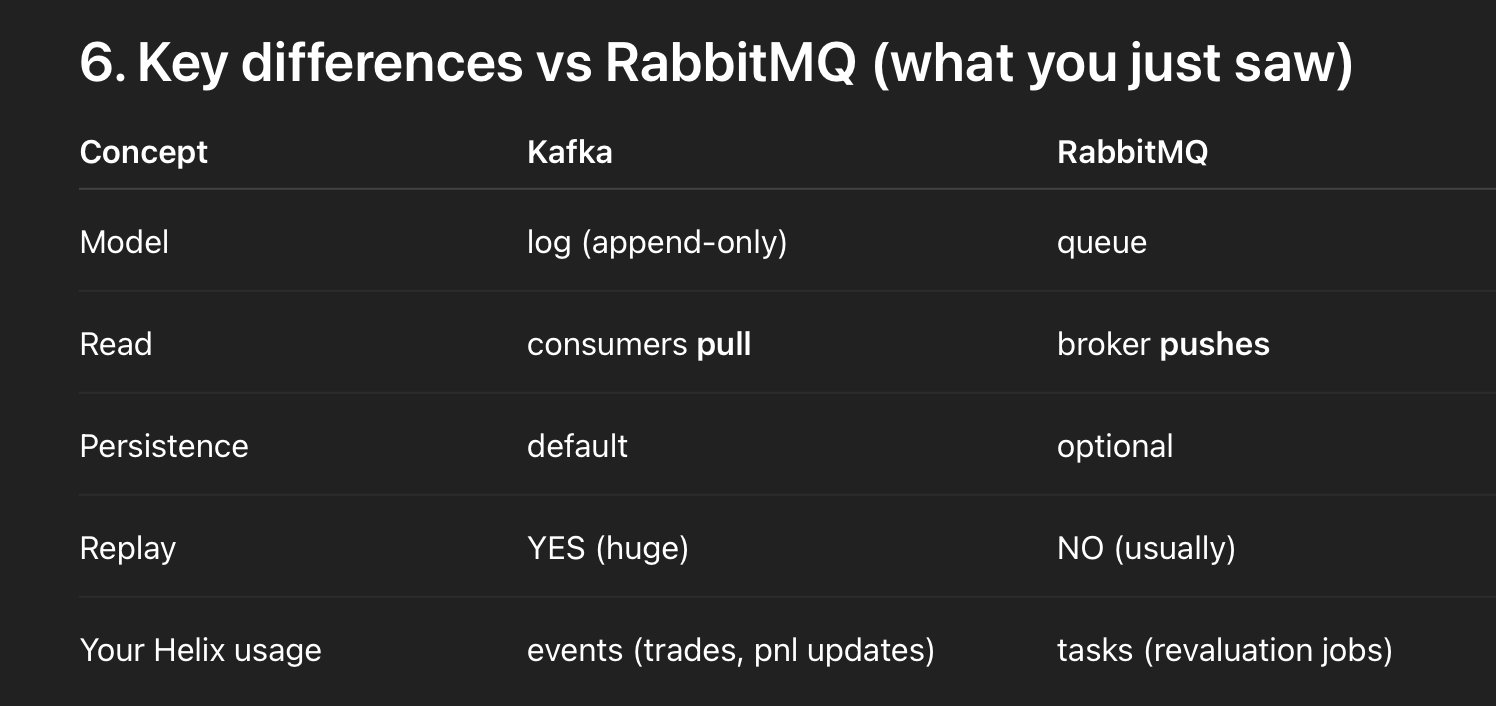

In [ ]:
!pip install pika

In [ ]:
!pip install kafka-python

In [ ]:
from kafka import KafkaProducer
import json
import time

producer = KafkaProducer(
    bootstrap_servers='localhost:9092',
    value_serializer=lambda v: json.dumps(v).encode('utf-8')
)

topic = 'test-topic'

for i in range(3):
    message = {
        "event": "hello",
        "id": i,
        "text": f"Hello Kafka #{i}"
    }
    producer.send(topic, message)
    print(f"[x] Sent: {message}")
    time.sleep(1)

producer.flush()

In [ ]:
from kafka import KafkaConsumer
import json

consumer = KafkaConsumer(
    'test-topic',
    bootstrap_servers='localhost:9092',
    auto_offset_reset='earliest',
    enable_auto_commit=True,
    group_id='test-group',
    value_deserializer=lambda x: json.loads(x.decode('utf-8'))
)

print("\n--- Listening ---")

for msg in consumer:
    print(f"[x] Received: {msg.value}")

In [ ]:
from kafka import KafkaConsumer
import json

consumer = KafkaConsumer(
    'test-topic',
    bootstrap_servers='localhost:9092',
    auto_offset_reset='earliest',   # 👈 key line
    enable_auto_commit=False,       # 👈 don't move offset forward
    group_id=None,                  # 👈 no group → always fresh read
    value_deserializer=lambda x: json.loads(x.decode('utf-8'))
)

print("\n--- REPLAY FROM BEGINNING ---")

for msg in consumer:
    print(f"[x] Replayed: {msg.value}")